# Experiment 1 — Quantization Perplexity

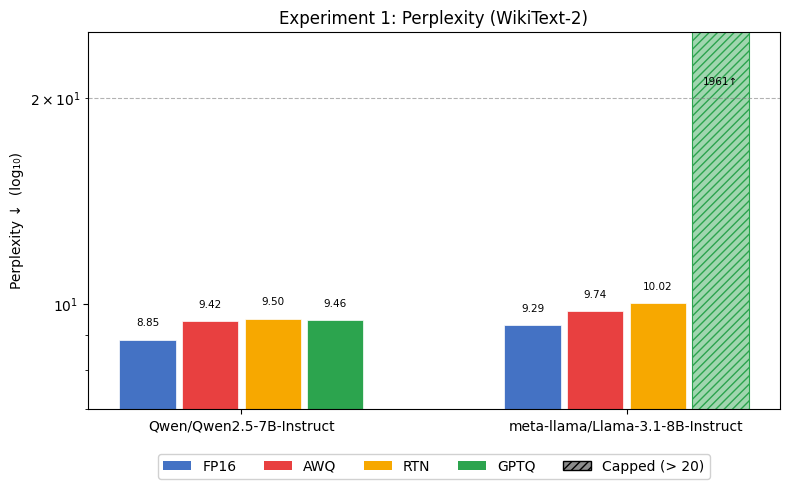

In [2]:
import json
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.colors as mcolors
import numpy as np

exp1 = json.load(open("results/exp1.json"))

# ── Adjustable ──────────────────────────────────────────────────────────────
PPL_CAP   = 20   # y-axis ceiling — lower = broken bar appears shorter
LOG_BASE  = 10    # log base for tick labels only; try 2, None=linear
Y_MIN     = 7.0   # y-axis floor
LIGHTEN_F = 0.55  # 0=full tech colour, 1=white for the capped bar fill
# ────────────────────────────────────────────────────────────────────────────
# Note: changing LOG_BASE does not change relative bar heights (mathematically
# equivalent across bases). PPL_CAP is the real knob — lower it to visually
# shrink the broken bar and give the good-result bars more screen real estate.
# ────────────────────────────────────────────────────────────────────────────

selected = [e for e in exp1 if e.get("selected")]

def parse_entry(e):
    src = e.get("model", "") or e.get("weight_path", "")
    family = "Qwen" if "Qwen" in src else "Llama"
    wp = e.get("weight_path", "")
    if   "rtn"  in wp: mode = "rtn"
    elif "gptq" in wp: mode = "gptq"
    elif "awq"  in wp: mode = "awq"
    else:               mode = "fp16"
    return (family, mode, e.get("perplexity", 9999))

def lighten(hex_color, f):
    r, g, b = mcolors.to_rgb(hex_color)
    return (r + (1-r)*f, g + (1-g)*f, b + (1-b)*f)

best = {}
for e in selected:
    fam, mode, ppl = parse_entry(e)
    key = (fam, mode)
    if key not in best or ppl < best[key]:
        best[key] = ppl

families     = ["Qwen", "Llama"]
family_names = {
    "Qwen":  "Qwen/Qwen2.5-7B-Instruct",
    "Llama": "meta-llama/Llama-3.1-8B-Instruct",
}
techniques  = ["fp16", "awq", "rtn", "gptq"]
tech_labels = {"fp16": "FP16", "awq": "AWQ", "rtn": "RTN", "gptq": "GPTQ"}
tech_colors = {"fp16": "#4472C4", "awq": "#E84040", "rtn": "#F7A800", "gptq": "#2CA44E"}

present = [t for t in techniques if any(best.get((f, t)) for f in families)]

x = np.arange(len(families))
n = len(present)
w = 0.65 / n

fig, ax = plt.subplots(figsize=(8, 5))

for i, tech in enumerate(present):
    offset = (i - n / 2 + 0.5) * w
    for j, fam in enumerate(families):
        v = best.get((fam, tech))
        if v is None:
            continue
        broken    = v > PPL_CAP
        bar_color = lighten(tech_colors[tech], LIGHTEN_F) if broken else tech_colors[tech]

        # Draw at actual value; matplotlib clips at ylim automatically
        ax.bar(x[j] + offset, v, w * 0.9,
               color=bar_color,
               hatch="////" if broken else None,
               edgecolor=tech_colors[tech] if broken else "white",
               linewidth=0.8 if broken else 0.5)

        if broken:
            # Full tech colour contrasts well against the lightened background
            ax.text(x[j] + offset, PPL_CAP * 1.04, f"{int(round(v))}↑",
                    ha="center", va="bottom", fontsize=7.5,
                    color="black")
        else:
            y_lbl = v * 1.04 if LOG_BASE else v + 0.05
            ax.text(x[j] + offset, y_lbl, f"{v:.2f}",
                    ha="center", va="bottom", fontsize=7.5)

ax.axhline(PPL_CAP, color="gray", linestyle="--", linewidth=0.8, alpha=0.6)

if LOG_BASE:
    ax.set_yscale("log", base=LOG_BASE)
ax.set_ylim(bottom=Y_MIN, top=PPL_CAP * 1.25)

ax.set_xticks(x)
ax.set_xticklabels([family_names[f] for f in families], rotation=0, ha="center")
scale_note = {10: "  (log₁₀)", 2: "  (log₂)"}.get(LOG_BASE, "")
ax.set_ylabel(f"Perplexity ↓{scale_note}")
ax.set_title("Experiment 1: Perplexity (WikiText-2)")

legend_handles = [mpatches.Patch(facecolor=tech_colors[t], label=tech_labels[t]) for t in present]
capped_tech = next((t for t in present if any((best.get((f, t)) or 0) > PPL_CAP for f in families)), None)
if capped_tech:
    legend_handles.append(mpatches.Patch(
        facecolor=lighten("black", LIGHTEN_F),
        hatch="////", edgecolor="black",
        label=f"Capped (> {PPL_CAP})"
    ))
ax.legend(handles=legend_handles, loc="upper center",
          bbox_to_anchor=(0.5, -0.1), ncol=len(legend_handles), framealpha=0.9)
plt.tight_layout()
plt.show()


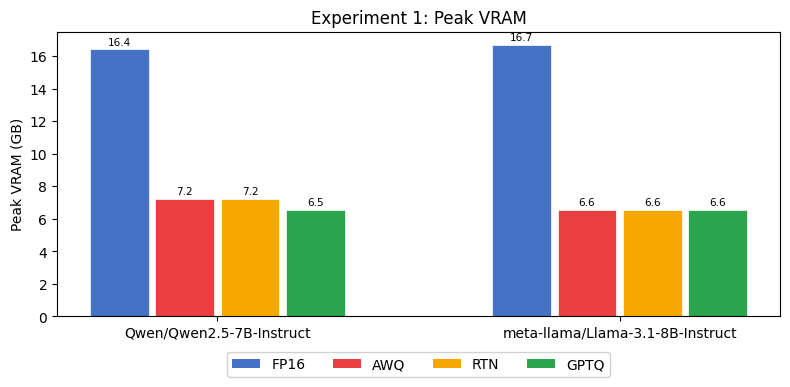

In [3]:
vram_best = {}
for e in selected:
    fam, mode, _ = parse_entry(e)
    v = e.get("peak_vram_gb")
    if v is None:
        continue
    key = (fam, mode)
    if key not in vram_best or v < vram_best[key]:
        vram_best[key] = v

fig, ax = plt.subplots(figsize=(8, 4))

for i, tech in enumerate(present):
    offset = (i - n / 2 + 0.5) * w
    for j, fam in enumerate(families):
        v = vram_best.get((fam, tech))
        if v is None:
            continue
        ax.bar(x[j] + offset, v, w * 0.9, color=tech_colors[tech], edgecolor="white", linewidth=0.5)
        ax.text(x[j] + offset, v + 0.15, f"{v:.1f}", ha="center", va="bottom", fontsize=7.5)

ax.set_xticks(x)
ax.set_xticklabels([family_names[f] for f in families], rotation=0, ha="center")
ax.set_ylabel("Peak VRAM (GB)")
ax.set_title("Experiment 1: Peak VRAM")
ax.set_ylim(bottom=0)

legend_handles = [mpatches.Patch(facecolor=tech_colors[t], label=tech_labels[t]) for t in present]
ax.legend(handles=legend_handles, loc="upper center",
          bbox_to_anchor=(0.5, -0.1), ncol=len(legend_handles), framealpha=0.9)
plt.tight_layout()
plt.show()

# Experiment 2 — End-to-end Prefill / Decode

In [2]:
import json, pandas as pd
from IPython.display import display

exp2 = json.load(open("results/exp2.json"))
print(f"Device: {exp2['device']}\n")

for metric, label in [("decode_tok_per_s", "Decode tok/s"), ("prefill_tok_per_s", "Prefill tok/s")]:
    rows = {}
    for kernel, kd in exp2["e2e"].items():
        rows[kernel] = {e["batch_size"]: round(e[metric], 1) for e in kd["by_batch"]}
    if metric == "decode_tok_per_s" and "vllm_reference" in exp2:
        rows["vllm"] = {e["batch_size"]: round(e["decode_tok_per_s"], 1)
                        for e in exp2["vllm_reference"]["by_batch"]}
    df = pd.DataFrame(rows).T
    df.columns.name = "batch_size"
    df.index.name = "kernel"
    print(f"=== {label} ===")
    display(df)
    print()

vram = {k: f"{v['peak_vram_gb']:.1f} GB" for k, v in exp2["e2e"].items()}
print("Peak VRAM:", vram)

Device: NVIDIA A10

=== Decode tok/s ===


batch_size,1,4,16,32
kernel,,,,
triton,5.0,19.6,77.4,146.4
vanilla,1.7,6.8,27.0,53.5
marlin,31.6,124.4,484.9,974.9
fp16_baseline,27.5,106.7,382.0,677.7
vllm,79.3,315.6,1138.3,1867.8



=== Prefill tok/s ===


batch_size,1,4,16,32
kernel,,,,
triton,1244.5,1322.5,1243.6,1245.6
vanilla,463.5,665.3,754.3,806.3
marlin,3456.2,3299.8,3385.4,3277.3
fp16_baseline,3598.5,3821.8,4073.1,4019.2



Peak VRAM: {'triton': '11.8 GB', 'vanilla': '11.8 GB', 'marlin': '11.8 GB', 'fp16_baseline': '21.3 GB'}


# Experiment 3 — GSM8k / MMLU Accuracy

In [5]:
import json
import pandas as pd
from IPython.display import display

exp3 = json.load(open("results/exp3.json"))

DATASET_LABELS = {"gsm8k": "GSM8k", "mmlu": "MMLU"}
METHOD_ORDER   = ["FP16", "AWQ", "RTN", "GPTQ"]

def _parse_exp3(e):
    src = e.get("model", "") or e.get("weight_path", "")
    fam = "Qwen" if "Qwen" in src else "Llama"
    wp  = e.get("weight_path", "")
    if   "rtn"  in wp: method = "RTN"
    elif "gptq" in wp: method = "GPTQ"
    elif "awq"  in wp: method = "AWQ"
    else:               method = "FP16"
    return fam, method

def show_exp3(family="Qwen", datasets=("gsm8k", "mmlu")):
    """
    family   : "Qwen" or "Llama"
    datasets : any non-empty subset of ("gsm8k", "mmlu")
    """
    merged = {}
    for e in exp3:
        if not e.get("selected"):
            continue
        fam, method = _parse_exp3(e)
        key = (fam, method)
        if key not in merged:
            merged[key] = {}
        for ds in ("gsm8k", "mmlu"):
            if ds in e:
                merged[key][ds] = e[ds]

    rows = []
    for method in METHOD_ORDER:
        d = merged.get((family, method))
        if d is None:
            continue
        row = {"Method": method}
        for ds in datasets:
            v = d.get(ds)
            row[DATASET_LABELS[ds]] = f"{v*100:.1f}%" if v is not None else "—"
        rows.append(row)

    df = pd.DataFrame(rows).set_index("Method")

    def _style(df):
        s = df.style
        for col in df.columns:
            nums = {i: float(v.rstrip("%")) for i, v in df[col].items() if v != "—"}
            if not nums:
                continue
            best = max(nums, key=nums.get)
            s = s.set_properties(subset=pd.IndexSlice[[best], [col]],
                                  **{"font-weight": "bold", "background-color": "#e8f5e9"})
        return s

    print(f"Exp3: Accuracy — {family}  |  {', '.join(DATASET_LABELS[d] for d in datasets)}")
    display(_style(df))

show_exp3("Qwen", ("gsm8k", "mmlu"))
show_exp3("Llama", ("gsm8k", "mmlu"))


Exp3: Accuracy — Qwen  |  GSM8k, MMLU


,GSM8k,MMLU
Method,,
FP16,72.7%,72.6%
AWQ,70.7%,71.5%
RTN,78.6%,71.6%
GPTQ,61.8%,71.7%


Exp3: Accuracy — Llama  |  GSM8k, MMLU


,GSM8k,MMLU
Method,,
FP16,76.7%,67.0%
AWQ,69.1%,64.9%
RTN,68.5%,65.0%
GPTQ,71.9%,65.8%


# Experiment 4 — GEMM Roofline

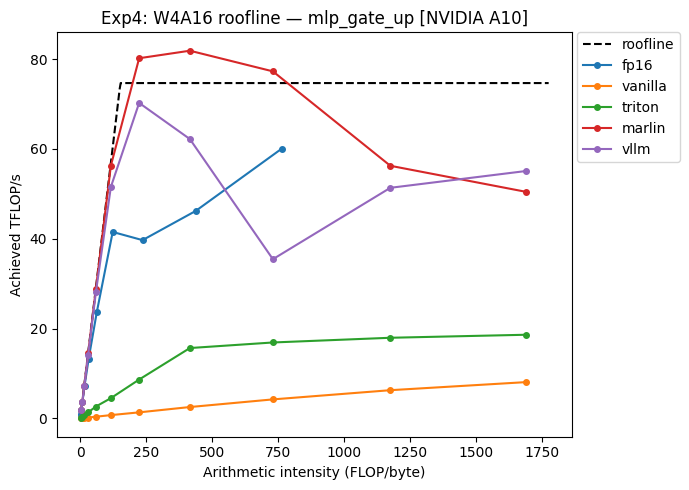

In [7]:
import json
import numpy as np
import matplotlib.pyplot as plt

exp4 = json.load(open("results/exp4.json"))

def plot_roofline(results, mode="scatter", shape="mlp_gate_up"):
    peak_tflops = results["hardware"]["peak_tflops_fp16"]
    peak_bw     = results["hardware"]["peak_bw_gbps"]
    all_intensities = [r["intensity"] for r in results["gemm_roofline"] if r["shape"] == shape]
    x_max = max(all_intensities) * 1.05 if all_intensities else 2000
    xs = np.linspace(0, x_max, 500)
    fig, ax = plt.subplots(figsize=(7, 5))
    ax.plot(xs, [min(peak_tflops, peak_bw * x / 1e3) for x in xs], "k--", label="roofline")
    markers = {"fp16": "o", "vanilla": "s", "triton": "^", "marlin": "D", "vllm": "*"}
    colors  = {"fp16": "C0", "vanilla": "C1", "triton": "C2", "marlin": "C3", "vllm": "C4"}
    for kname in markers:
        pts = sorted(
            [(r["intensity"], r["tflops"]) for r in results["gemm_roofline"]
             if r["kernel"] == kname and r["shape"] == shape],
            key=lambda p: p[0],
        )
        if not pts: continue
        xs_k, ys_k = zip(*pts)
        if mode == "line":
            ax.plot(xs_k, ys_k, marker="o", markersize=4, color=colors[kname], label=kname)
        else:
            ax.scatter(xs_k, ys_k, marker=markers[kname], s=5, color=colors[kname], label=kname)
    ax.set_xlabel("Arithmetic intensity (FLOP/byte)")
    ax.set_ylabel("Achieved TFLOP/s")
    ax.set_title(f"Exp4: W4A16 roofline — {shape} [{results['hardware']['device']}]")
    ax.legend(loc="upper left", bbox_to_anchor=(1.01, 1), borderaxespad=0)
    plt.tight_layout()
    plt.show()

plot_roofline(exp4, mode="line")